In [806]:
#Importing Necessary Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [807]:
# Loading the dataset
car_dataset=pd.read_csv('C:\\Users\\USER\\Desktop\\CodeAlpha\\car data.csv')

In [808]:
#Inspecting the first 5 rows of the dataset
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [809]:
# Checking the number of rows and columns
car_dataset.shape

(301, 9)

In [810]:
# Checking the overall information about the dataset
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [811]:
# Double checking for missing values
car_dataset.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [812]:
print(car_dataset.Fuel_Type.value_counts())
print(car_dataset.Selling_type.value_counts())
print(car_dataset.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


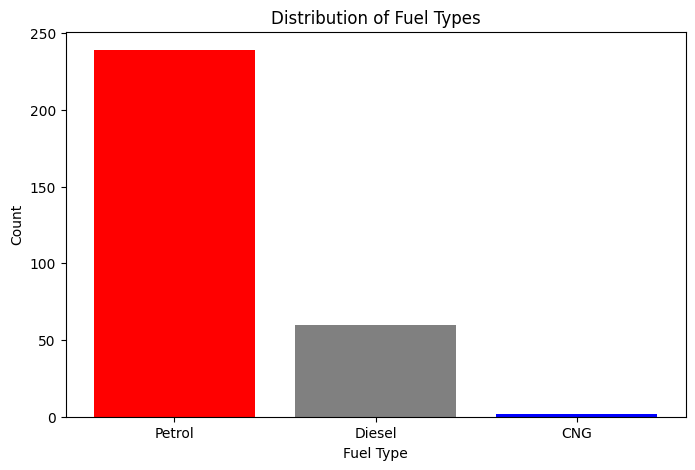

In [813]:
plt.figure(figsize=(8,5))
plt.bar(car_dataset.Fuel_Type.value_counts().index, car_dataset.Fuel_Type.value_counts().values, color=['red', 'grey', 'blue'])
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.title('Distribution of Fuel Types')
plt.show()

In [814]:
# Encoding Categorical Data into Numerical Data to be fit for Machine Learning.
car_dataset.replace({'Fuel_Type':{'Petrol':0, 'Diesel':1, 'CNG':2}}, inplace=True)
car_dataset.replace({'Selling_type':{'Dealer':0, 'Individual':1}}, inplace=True)
car_dataset.replace({'Transmission':{'Manual':0, 'Automatic':1}}, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_10328\1402290255.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Fuel_Type':{'Petrol':0, 'Diesel':1, 'CNG':2}}, inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_10328\1402290255.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Selling_type':{'Dealer':0, 'Individual':1}}, inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_10328\1402290255.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed

In [815]:
# Splitting the data and Target
X= car_dataset.drop(['Car_Name','Selling_Price'], axis=1)
Y= car_dataset['Selling_Price']

In [816]:
print(X)
print(Y)

     Year  Present_Price  Driven_kms  Fuel_Type  Selling_type  Transmission  \
0    2014           5.59       27000          0             0             0   
1    2013           9.54       43000          1             0             0   
2    2017           9.85        6900          0             0             0   
3    2011           4.15        5200          0             0             0   
4    2014           6.87       42450          1             0             0   
..    ...            ...         ...        ...           ...           ...   
296  2016          11.60       33988          1             0             0   
297  2015           5.90       60000          0             0             0   
298  2009          11.00       87934          0             0             0   
299  2017          12.50        9000          1             0             0   
300  2016           5.90        5464          0             0             0   

     Owner  
0        0  
1        0  
2        0  

In [817]:
# Splitting Trainning and Testing Data
X_train, X_test, Y_train, Y_test= train_test_split(X,Y, test_size=0.2, random_state=2)

In [818]:
# Model Training
lin_reg_model= LinearRegression()
lin_reg_model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [819]:
# Model Evaluation
training_data_prediction= lin_reg_model.predict(X_train)

In [820]:
# Using R Squared Error to evaluate the model
error_score= metrics.r2_score(Y_train,training_data_prediction)
print('R Squared Error:', error_score)

R Squared Error: 0.8834899874176637


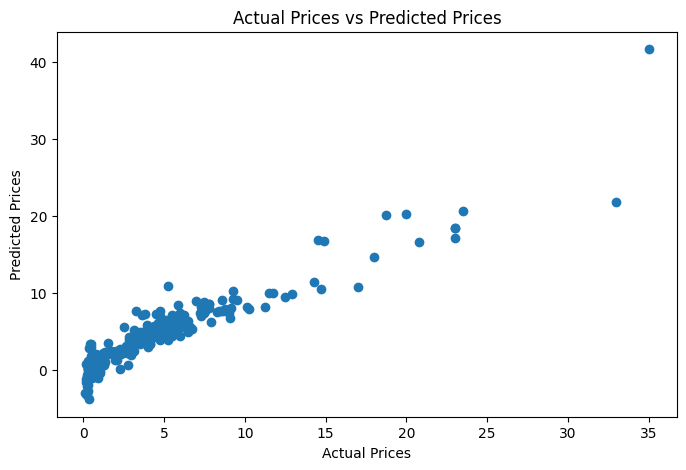

In [821]:
# Visualize the actual prices and predicted prices
plt.figure(figsize=(8,5))


plt.scatter(Y_train, training_data_prediction)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual Prices vs Predicted Prices')
plt.show()

In [822]:
# Predicting the prices of the test data
test_data_prediction= lin_reg_model.predict(X_test)
error_score= metrics.r2_score(Y_test, test_data_prediction)
print('R Squared Error:', error_score)

R Squared Error: 0.8401415675614679


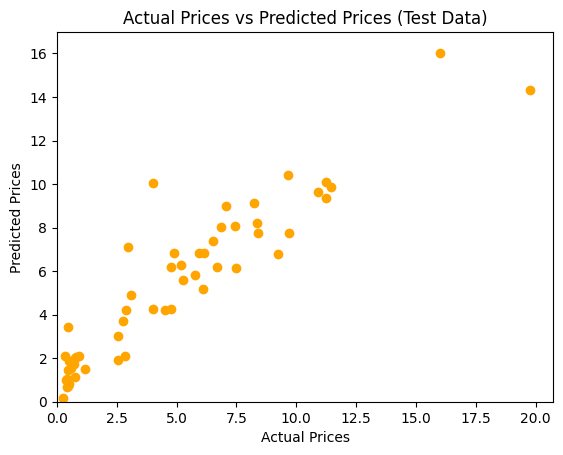

In [823]:

plt.scatter(Y_test, test_data_prediction, color='orange')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.ylim(bottom=0)
plt.xlim(left=0) 

plt.title('Actual Prices vs Predicted Prices (Test Data)')
plt.show()